In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [3]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [4]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True) 
train_dataset, test_dataset = dataset['train'], dataset['test'] 

In [5]:
class_names = [ 
'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro', 'Cinco', 'Seis', 'Siete', 
'Ocho', 'Nueve' 
] 

In [6]:
num_train_examples = metadata.splits['train'].num_examples #60 mil datos train 
num_test_examples = metadata.splits['test'].num_examples #10 mil datos test 

In [7]:
#Normalizar: Numeros de 0 a 255, que sean de 0 a 1 
def normalize(images, labels): 
    images = tf.cast(images, tf.float32) 
    images /= 255 
    return images, labels 

In [8]:
train_dataset = train_dataset.map(normalize) 
test_dataset = test_dataset.map(normalize) 

In [9]:
#Estructura de la red 
model = tf.keras.Sequential([ 
tf.keras.layers.Flatten(input_shape=(28,28,1)), #Capa de entrada 
tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta 
tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta 
tf.keras.layers.Dense(10, activation=tf.nn.softmax) #para clasificacion 
])

c:\Users\angel\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
#Función que compila el modelo 
model.compile( 
optimizer='adam', 
loss='sparse_categorical_crossentropy', 
metrics=['accuracy'] 
)

In [11]:
#Aprendizaje por lotes de 32 cada lote 
BATCHSIZE = 32 
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE) 
test_dataset = test_dataset.batch(BATCHSIZE) 

In [12]:
#Realizar el aprendizaje 
model.fit( 
train_dataset, epochs=5, 
steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE) 
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9194 - loss: 0.2784
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9637 - loss: 0.1211
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9726 - loss: 0.0896
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9793 - loss: 0.0682
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0557


In [13]:
#Evaluar nuestro modelo ya entrenado, contra el dataset de pruebas 
test_loss, test_accuracy = model.evaluate( 
test_dataset, steps=math.ceil(num_test_examples/32) 
) 
#Imprime los resultados de precisión 
print("Resultado en las pruebas: ", test_accuracy) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9713 - loss: 0.0964
Resultado en las pruebas:  0.9713000059127808


In [14]:
for test_images, test_labels in test_dataset.take(1): 
  test_images = test_images.numpy() 
  test_labels = test_labels.numpy() 
  predictions = model.predict(test_images) 
 
def plot_image(i, predictions_array, true_labels, images): 
  predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i] 
  plt.grid(False) 
  plt.xticks([]) 
  plt.yticks([]) 
 
  plt.imshow(img[...,0], cmap=plt.cm.binary) 
 
  predicted_label = np.argmax(predictions_array) 
  if predicted_label == true_label: 
    color = 'blue' 
  else: 
    color = 'red' 
 
  plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color) 
 
def plot_value_array(i, predictions_array, true_label): 
  predictions_array, true_label = predictions_array[i], true_label[i] 
  plt.grid(False) 
  plt.xticks([]) 
  plt.yticks([]) 
  thisplot = plt.bar(range(10), predictions_array, color="#888888") 
  plt.ylim([0,1]) 
  predicted_label = np.argmax(predictions_array) 
 
  thisplot[predicted_label].set_color('red') 
  thisplot[true_label].set_color('blue') 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


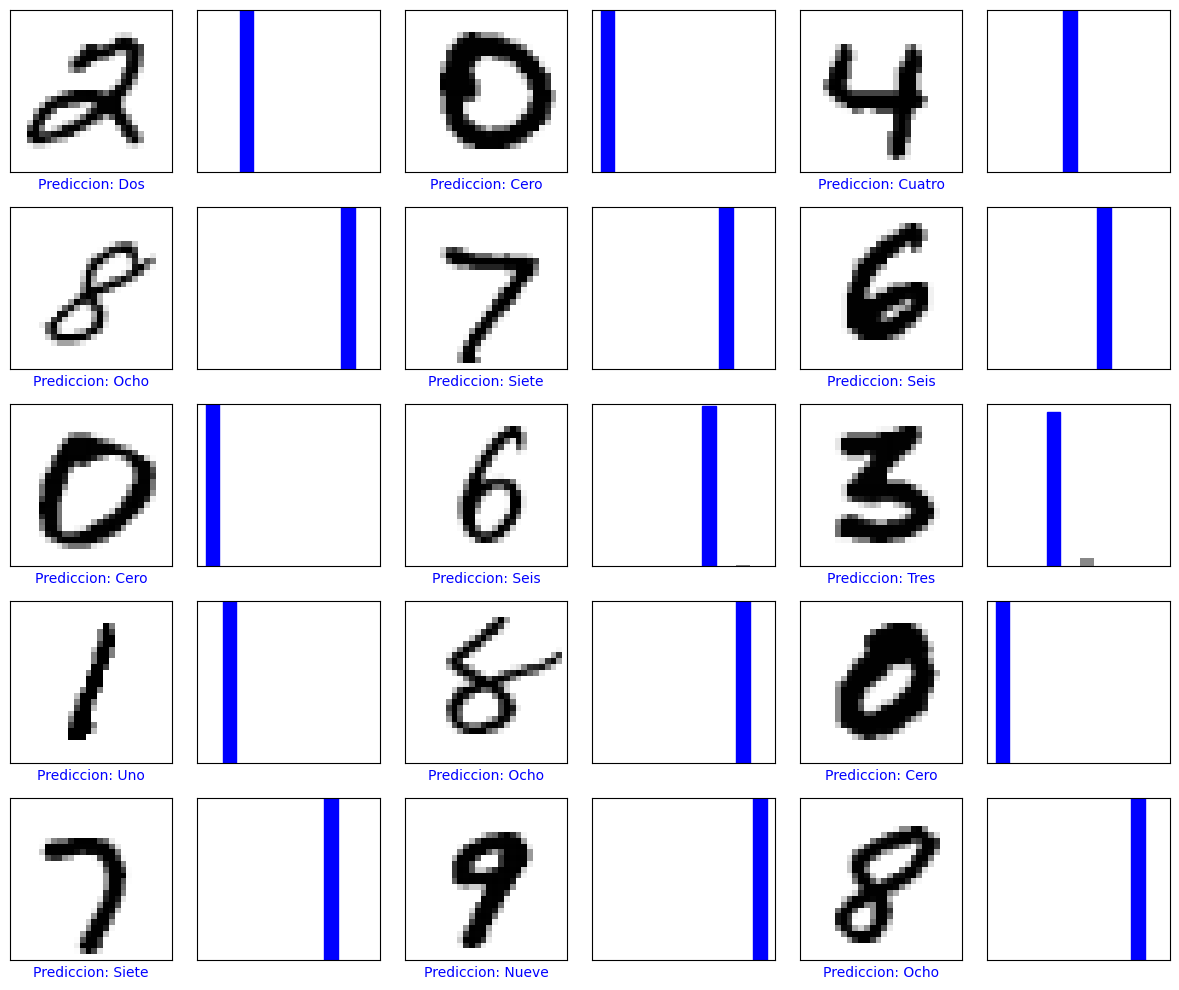

In [15]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    # Imagen con predicción
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    
    # Barra de probabilidades
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()

In [16]:
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler

In [17]:
import webbrowser, os
webbrowser.open("file://" + os.path.abspath("index.html"))

True

In [ ]:
import http.server
import socketserver
import json
import numpy as np
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler

class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):

    def do_GET(self):
        # Servir el archivo index.html
        if self.path == '/' or self.path == '/index.html':
            with open('index.html', 'rb') as f:
                content = f.read()
            self.send_response(200)
            self.send_header("Content-Type", "text/html; charset=utf-8")
            self.end_headers()
            self.wfile.write(content)

    def do_OPTIONS(self):
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Access-Control-Allow-Methods", "POST, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "Content-Type, Content-Length")
        self.end_headers()

    def do_POST(self):
        print("Peticion recibida")
        content_length = int(self.headers['Content-Length'])
        data = self.rfile.read(content_length)
        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)

        arr = np.fromstring(data, np.float32, sep=",")
        arr = arr.reshape(28, 28)
        arr = np.array(arr)
        arr = arr.reshape(1, 28, 28, 1)

        prediction_values = model.predict(arr, batch_size=1)
        prediction = str(np.argmax(prediction_values))
        print("Prediccion final: " + prediction)

        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.send_header("Content-Type", "text/plain")
        self.end_headers()
        self.wfile.write(prediction.encode())

    def log_message(self, format, *args):
        pass

print("Iniciando el servidor...")
print("Abre en el navegador: http://localhost:8000")
server = HTTPServer(('localhost', 8000), SimpleHTTPRequestHandler)
server.serve_forever()

Iniciando el servidor...
Abre en el navegador: http://localhost:8000
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Prediccion final: 5
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediccion final: 5
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediccion final: 2
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediccion final: 3
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediccion final: 2
